<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/16_unction_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/train.csv", usecols=["Age","Fare","Survived"])

In [3]:
df.head(2)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833


In [4]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [5]:
X=df.iloc[:,1:3]
y=df.iloc[:,0:1]

In [10]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)
X_train.head(2)

,Age,Fare
331,45.5,28.5
733,23.0,13.0


In [36]:
column_trasformer=ColumnTransformer([
    ("trf1", SimpleImputer(), ["Age"])

],remainder="passthrough")

In [38]:
X_train_trans=column_trasformer.fit_transform(X_train)
X_test_trans=column_trasformer.transform(X_test)

In [41]:
trf = FunctionTransformer(func=np.log1p)
X_train_trans_ft=trf.fit_transform(X_train_trans)
X_test_trans_ft=trf.transform(X_test_trans)

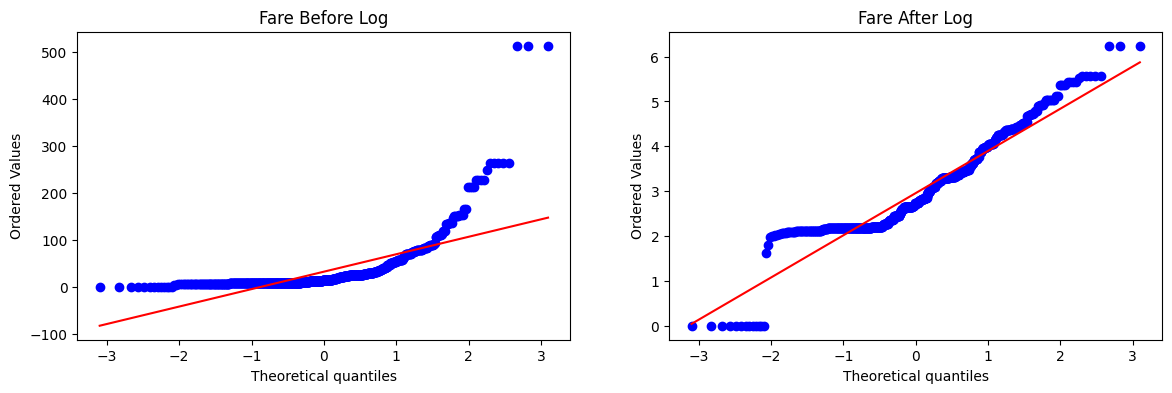

In [47]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122) # Changed to 122 to display side-by-side
stats.probplot(X_train_trans_ft[:, 1], dist="norm", plot=plt) # Corrected index for Fare after transformation
plt.title('Fare After Log')

plt.show()

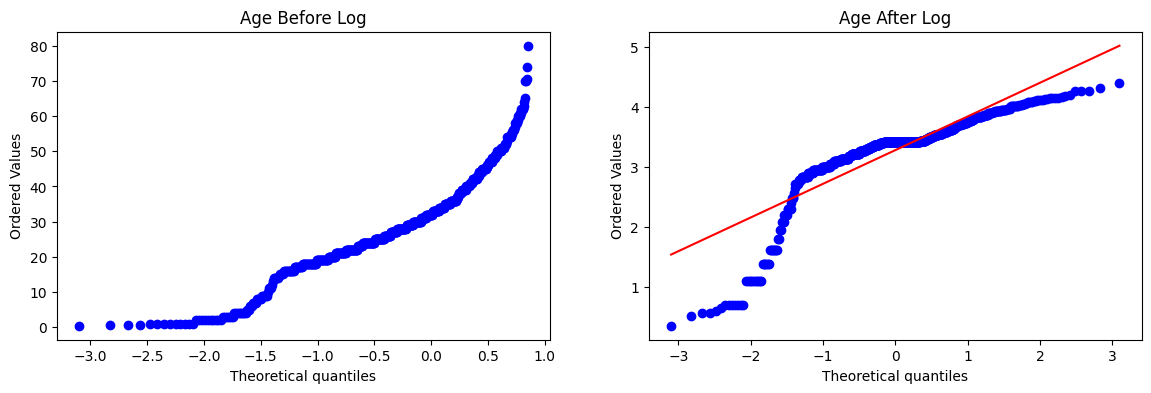

In [48]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122) # Changed to 122 to display side-by-side
stats.probplot(X_train_trans_ft[:, 0], dist="norm", plot=plt) # Corrected index for Fare after transformation
plt.title('Age After Log')

plt.show()

In [49]:
lr=LogisticRegression()
lr.fit(X_train_trans_ft, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [50]:
y_pred=lr.predict(X_test_trans_ft)

In [51]:
accuracy_score(y_pred,y_test)

0.6815642458100558

In [62]:
def apply_transform(transform):

  X=df.iloc[:,1:3]
  y=df.iloc[:,0:1]

  column_trasformer=ColumnTransformer([("trf1", SimpleImputer(), ["Age"])],remainder="passthrough")

  X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

  X_train_trans=column_trasformer.fit_transform(X_train)
  X_test_trans=column_trasformer.transform(X_test)

  trf = FunctionTransformer(func=np.log1p)
  X_train_trans_ft=trf.fit_transform(X_train_trans)
  X_test_trans_ft=trf.transform(X_test_trans)

  lr=LogisticRegression()
  lr.fit(X_train_trans_ft, y_train)

  print("Accuracy",accuracy_score(lr.predict(X_test_trans_ft), y_test))

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  stats.probplot(X['Fare'], dist="norm", plot=plt)
  plt.title('Fare Before Transform')

  plt.subplot(122)
  stats.probplot(X_train_trans_ft[:,1], dist="norm", plot=plt)
  plt.title('Fare After Transform')

  plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy 0.6815642458100558


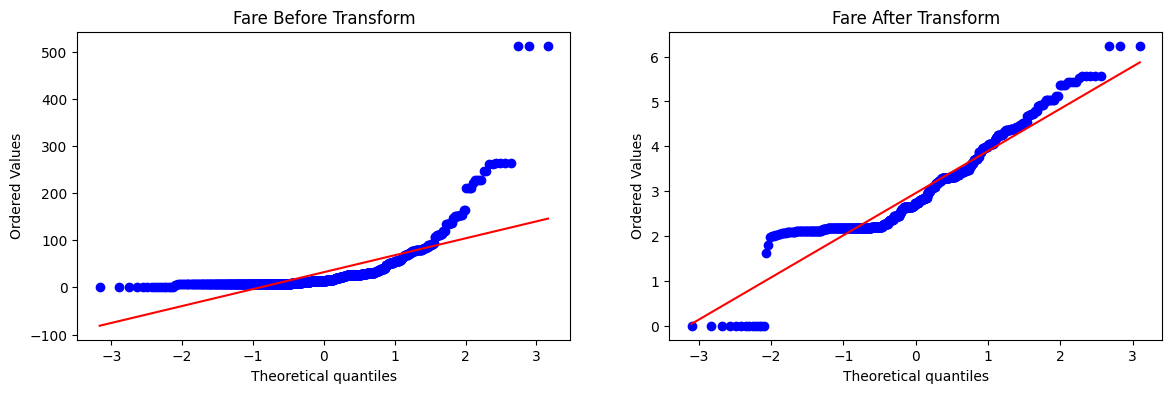

In [66]:
apply_transform(lambda X:np.sqrt(X))